In [84]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import sunpy
import sunpy.map
from sunpy.coordinates import get_earth, propagate_with_solar_surface
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
from astropy.coordinates import SkyCoord
import astropy.units as u
from ndcube import NDCube
from scipy.io import readsav
from skimage import measure
import skimage.measure.profile
from skimage.transform import rescale
import matplotlib.lines as mlines
import cv2
from ndcube.wcs.tools import unwrap_wcs_to_fitswcs


import importlib
import slit_interactive
importlib.reload(slit_interactive)
from slit_interactive import (SlitPick, plot_slit_position,
        remove_background, generate_slit_data_from_points,
        generate_straight_slit_data)

In [2]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

In [3]:
file_aia171_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/AIA_171_pr.hdf5")
aia171_pr_set = file_aia171_pr_dset["aia_171_img"]
aia171_pr_da = da.from_array(aia171_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))
aia171_pr_da = aia171_pr_da.compute()
aia171_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/AIA_171_date_obs.txt")["date_obs"])

In [89]:
hri_pr_noproj_array = np.load("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hri_no_proj_array_crop.npy")
hri_pr_noproj_array = hri_pr_noproj_array.transpose(2, 0, 1)
                                    

In [90]:
hrieuv_no_proj_extent = np.load("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hrieuv_no_proj_extent.npy")

hrieuv_nocrop_noproj_wcs = WCS(fits.getheader("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/hri_nocrop_noproj_wcs.fits",
                                        ignore_missing_simple=True))
hri_wcs = hrieuv_nocrop_noproj_wcs[hrieuv_no_proj_extent[1]:hrieuv_no_proj_extent[3] + 1,
                                hrieuv_no_proj_extent[0]:hrieuv_no_proj_extent[2] + 1]

In [88]:
hri_wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'HPLN-TAN' 'HPLT-TAN' 
CRVAL : 0.247880496491 0.17031781000819 
CRPIX : 896.5 960.5 
PC1_1 PC1_2  : 0.99683732876967 -0.079469113316786 
PC2_1 PC2_2  : 0.079469113316786 0.99683732876967 
CDELT : 0.00013666666666667 0.00013666666666667 
NAXIS : 0  0

In [19]:
hri_pr_noproj_array.shape

(360, 224, 245)

In [5]:
hrieuv_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/HRIEUV_date_ear.txt")["date_ear"])

In [7]:
aia_start_index = 3
aia171_date_obs[aia_start_index]

<Time object: scale='utc' format='isot' value=2022-10-24T19:04:45.349>

In [74]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin_4 = dkist_vbi_target_cube_crop.rebin((4,4))
dkist_vbi_target_cube_crop_rebin_8 = dkist_vbi_target_cube_crop.rebin((8,8))

aia_wcs = unwrap_wcs_to_fitswcs(dkist_vbi_target_cube_crop_rebin_8.wcs)[0]

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [91]:
x_select_df1  = np.array(
    [562.8, 512.5, 476.9, 427.0]
)/2

y_select_df1 = np.array(
    [459.5, 478.0, 486.0, 483.3]
)/2

x_select_df1_p = np.array(
    [122, 99.8]
)

y_select_df1_p = np.array(
    [113.5, 93.9]
)

#====================================================================================
x_select_df2 = np.array(
    [380, 336, 246]
)/2

y_select_df2 = np.array(
    [755, 775, 783]
)/2

x_select_df2_p = np.array(
    [92.7, 83.3, 72.9]
)

y_select_df2_p = np.array(
    [197.6, 190.3, 175.5]
)

#====================================================================================
x_select_df3 = np.array(
    [551.5, 533.4, 499.7,]
)/2

y_select_df3 = np.array(
    [626.0, 715.1, 882.8,]
)/2

x_select_df3_p = np.array(
    [127.4, 135.3, 152.6*0.75 + 0.25*183.1]
)

y_select_df3_p = np.array(
    [144.4, 164.8, 180.2*0.75 + 0.25*198.3]
)

#====================================================================================
x_select_df4 = np.array(
    [426, 350.6, 283.6]
)/2

y_select_df4 = np.array(
    [563.8, 535.9, 498.0]
)/2

x_select_df4_p = np.array(
    [98.1, 85.6, 80.6]
)

y_select_df4_p = np.array(
    [127.8, 112.4, 100.3]
)

#====================================================================================
x_select_ef1 = np.array(
    [396, 358, 322.4, 282, 242, 210, 178]
)/2

y_select_ef1 = np.array(
    [461, 433.5, 399, 346, 287, 232, 177]
)/2

x_select_ef1_p = np.array(
    [105.5, 100.1, 83.6, 78.3, 74.7]
)

y_select_ef1_p = np.array(
    [100.8, 93.3, 60.7, 45.4, 33.5]
)



slit_df1_result_dummy = generate_slit_data_from_points(
        x_select_df1, y_select_df1, np.zeros((aia171_pr_da.shape[1], aia171_pr_da.shape[2], 2)), "NDArray", line_width=4,
    )

slit_df1_p_result_dummy = generate_slit_data_from_points(
        x_select_df1_p, y_select_df1_p, np.zeros((hri_pr_noproj_array.shape[1], hri_pr_noproj_array.shape[2], 2)), "NDArray", line_width=4,
)

slit_df2_result_dummy = generate_slit_data_from_points(
        x_select_df2, y_select_df2, np.zeros((aia171_pr_da.shape[1], aia171_pr_da.shape[2], 2)), "NDArray", line_width=4,
    )

slit_df2_p_result_dummy = generate_slit_data_from_points(
        x_select_df2_p, y_select_df2_p, np.zeros((hri_pr_noproj_array.shape[1], hri_pr_noproj_array.shape[2], 2)), "NDArray", line_width=4,
)

slit_df3_result_dummy = generate_slit_data_from_points(
        x_select_df3, y_select_df3, np.zeros((aia171_pr_da.shape[1], aia171_pr_da.shape[2], 2)), "NDArray", line_width=4,
    )

slit_df3_p_result_dummy = generate_slit_data_from_points(
        x_select_df3_p, y_select_df3_p, np.zeros((hri_pr_noproj_array.shape[1], hri_pr_noproj_array.shape[2], 2)), "NDArray", line_width=4,
)

slit_df4_result_dummy = generate_slit_data_from_points(
        x_select_df4, y_select_df4, np.zeros((aia171_pr_da.shape[1], aia171_pr_da.shape[2], 2)), "NDArray", line_width=4,
    )

slit_df4_p_result_dummy = generate_slit_data_from_points(
        x_select_df4_p, y_select_df4_p, np.zeros((hri_pr_noproj_array.shape[1], hri_pr_noproj_array.shape[2], 2)), "NDArray", line_width=4,
)

slit_ef1_result_dummy = generate_slit_data_from_points(
        x_select_ef1, y_select_ef1, np.zeros((aia171_pr_da.shape[1], aia171_pr_da.shape[2], 2)), "NDArray", line_width=4,
    )

slit_ef1_p_result_dummy = generate_slit_data_from_points(
        x_select_ef1_p, y_select_ef1_p, np.zeros((hri_pr_noproj_array.shape[1], hri_pr_noproj_array.shape[2], 2)), "NDArray", line_width=4,
)



In [ ]:
def triangulation_fibril(
    slit_result, slit_p_result, 
    aia_time_lag, 
    aia_pixel,
    pseudo_height=0*u.Mm
    ):

    aia_time = aia171_date_obs[aia_start_index] + aia_time_lag

    aia_index = np.argmin(np.abs(aia171_date_obs - aia_time))
    hri_index = np.argmin(np.abs(hrieuv_date_obs - aia_time))

    print(aia_index, hri_index)

    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5), layout="constrained")

    ax1.imshow(aia171_pr_da[aia_index],
    origin="lower",
    interpolation="none",
    cmap="sdoaia171",
    norm=ImageNormalize(
        vmin=0,
        vmax=14.4,
        # stretch=AsinhStretch(),
    ))

    ax1.scatter(aia_pixel[0], aia_pixel[1], color="red", marker="x")

    fake_map = sunpy.map.Map(aia171_pr_da[aia_index], aia_wcs)
    hp_coords_aia = aia_wcs.pixel_to_world(aia_pixel[0], aia_pixel[1])
    hp_coords_aia = hp_coords_aia.make_3d()

    hp_coords_aia_with_height = SkyCoord(
        hp_coords_aia.Tx,
        hp_coords_aia.Ty,
        hp_coords_aia.distance - pseudo_height,
        frame=fake_map.coordinate_frame
    )

    with propagate_with_solar_surface():
        hri_pixel = hri_wcs.world_to_pixel(hp_coords_aia_with_height)

    ax2.imshow(hri_pr_noproj_array[hri_index],
    origin="lower",
    interpolation="none",
    cmap="sdoaia171",
    norm=ImageNormalize(
        vmin=850,
        vmax=11850,
        stretch=AsinhStretch(),
    ))

    ax2.scatter(hri_pixel[0], hri_pixel[1], color="red", marker="x")

    plot_slit_position(
        ax1,
        slit_result,
        show_control_points=True,
        show_legend=False,
        show_direction=True,
        show_curve=False,
        boundary_color="#58B2DC",
        triangle_color="#58B2DC",
    )

    plot_slit_position(
        ax2,
        slit_p_result,
        show_control_points=True,
        show_legend=False,
        show_direction=True,
        show_curve=False,
        boundary_color="#58B2DC",
        triangle_color="#58B2DC",
    )

    ax1.set_xlim((slit_result["pixels_idx"].min() - 30, slit_result["pixels_idx"].max() + 30))
    ax1.set_ylim((slit_result["pixels_idy"].min() - 30, slit_result["pixels_idy"].max() + 30))

    ax2.set_xlim((slit_p_result["pixels_idx"].min() - 30, slit_p_result["pixels_idx"].max() + 30))
    ax2.set_ylim((slit_p_result["pixels_idy"].min() - 30, slit_p_result["pixels_idy"].max() + 30))
    

45 99
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]


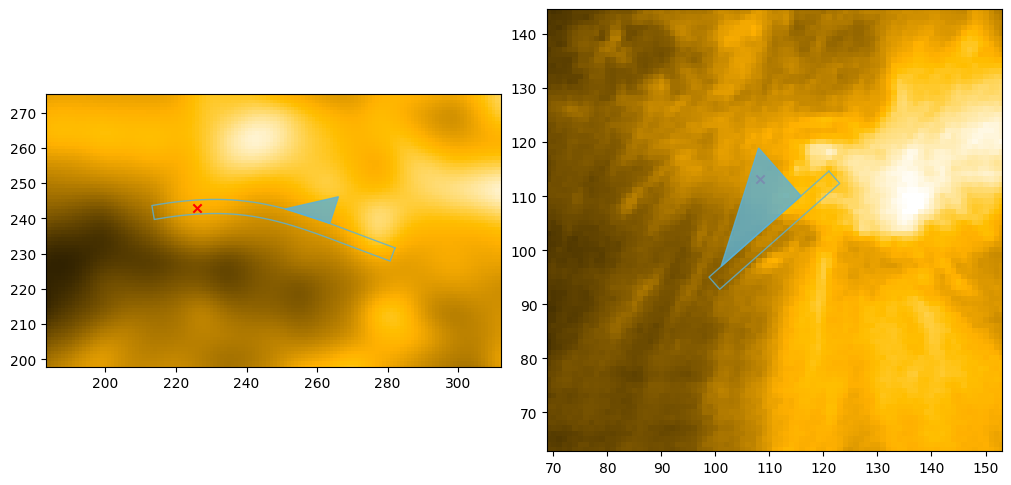

In [105]:
triangulation_fibril(
    slit_df1_result_dummy, slit_df1_p_result_dummy, 
    aia_time_lag=510*u.s,
    aia_pixel=[226, 243],
    pseudo_height=0*u.Mm
)

45 99
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]


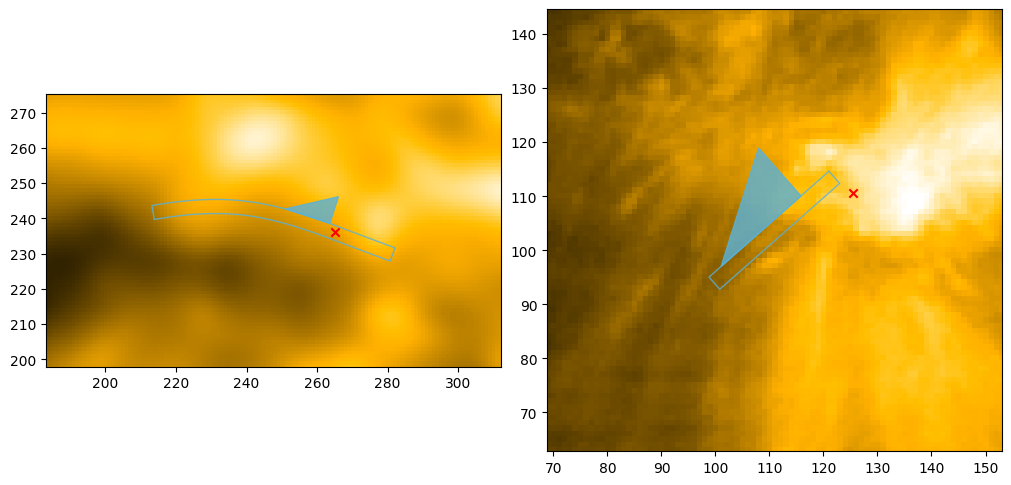

In [118]:
triangulation_fibril(
    slit_df1_result_dummy, slit_df1_p_result_dummy, 
    aia_time_lag=510*u.s,
    aia_pixel=[265, 236],
    pseudo_height=0*u.Mm
)

145 337
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]


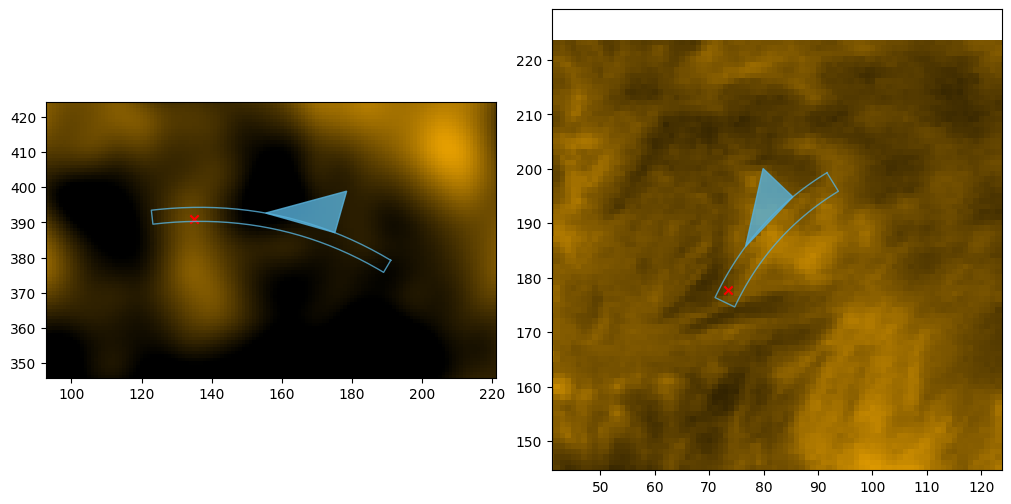

In [115]:
triangulation_fibril(
    slit_df2_result_dummy, slit_df2_p_result_dummy, 
    aia_time_lag=1700*u.s,
    aia_pixel=[135, 391],
    pseudo_height=3*u.Mm
)

86 197
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]


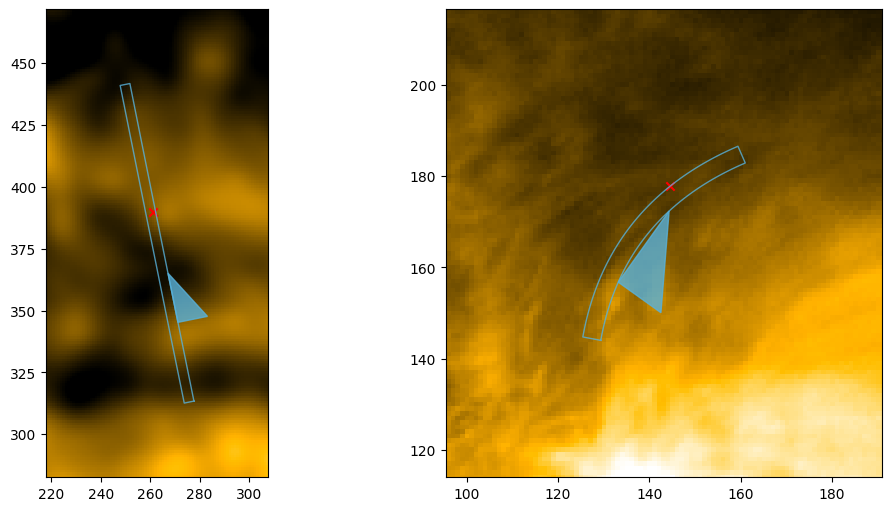

In [126]:
triangulation_fibril(
    slit_df3_result_dummy, slit_df3_p_result_dummy, 
    aia_time_lag=1000*u.s,
    aia_pixel=[261, 390],
    pseudo_height=6*u.Mm
)

111 257
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]


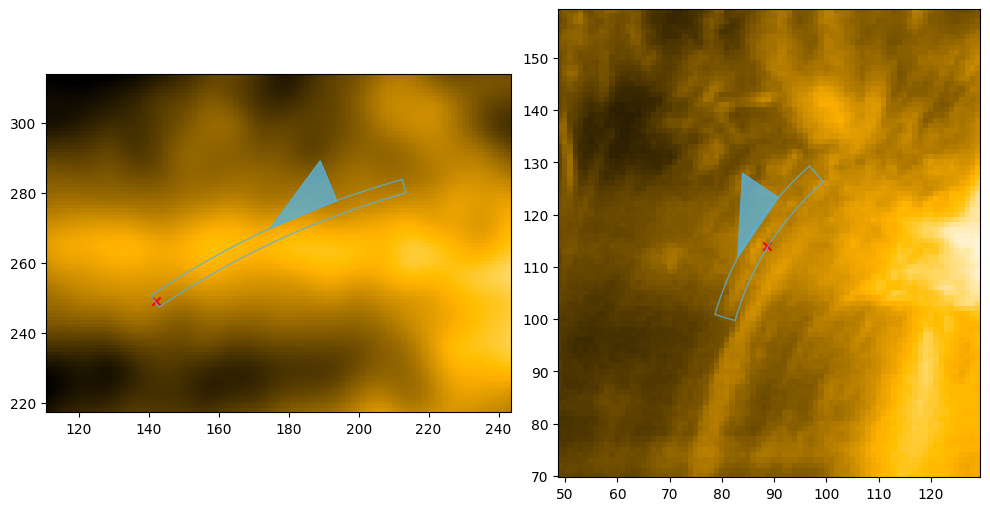

In [132]:
triangulation_fibril(
    slit_df4_result_dummy, slit_df4_p_result_dummy, 
    aia_time_lag=1300*u.s,
    aia_pixel=[142, 249],
    pseudo_height=3*u.Mm
)

36 77


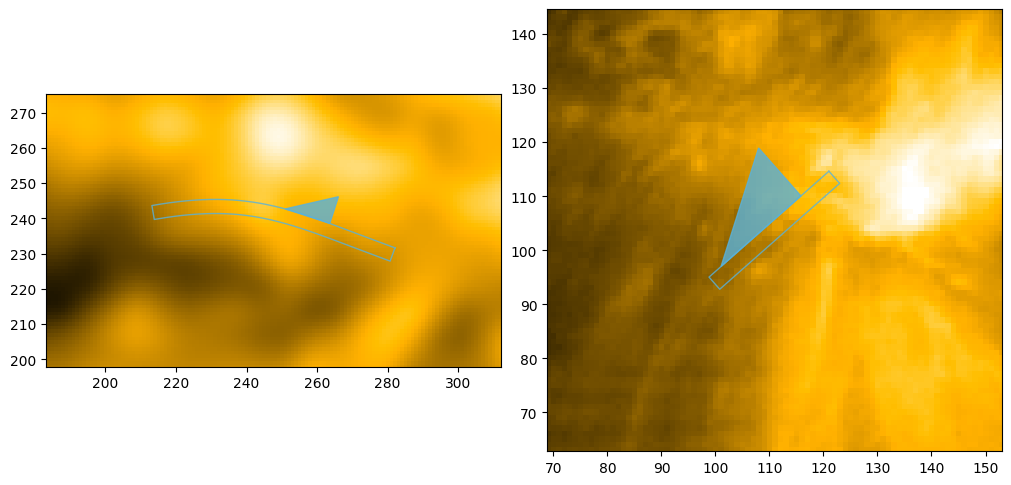

In [ ]:
triangulation_fibril(
    slit_df1_result_dummy, slit_df1_p_result_dummy, 
    aia_time_lag=400*u.s,
    aia_pixel=None,
)